In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import string
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
from nltk.probability import FreqDist
import pymorphy3

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

In [7]:
with open('2023.txt', 'r') as file:
    data = file.read()

In [9]:
stop_words = stopwords.words('russian')
morph = pymorphy3.MorphAnalyzer()

In [11]:
def tokenize_text(raw_text: str):
    """Функция для токенизации текста
    :param raw_text: исходная текстовая строка
    """
    # Разбиение на сслова при помощи пробела
    words = raw_text.split()
    # Подготовка регулярного выражения для фильтрации символов
    re_punc = re.compile('[%s]' % re.escape(string.punctuation))
    # Удаление знаков препинания
    stripped = [re_punc.sub('', w) for w in words]
    # Приведение всех слов к нижнему регистру
    words_lower = [w.lower() for w in stripped]
    # Удаление оставшихся токенов, которые не являются буквами
    words_alpha = [word for word in words_lower if word.isalpha()]
    # Удаление стоп-слов    
    words_stop = [w for w in words_alpha if not w in stop_words]
    # Лемматизация    
    tokens = [morph.parse(token)[0].normal_form for token in words_stop]
    # Удалим короткие токены
    tokens = [word for word in tokens if len(word) > 2]
      
    return tokens

In [13]:
tokenized = tokenize_text(data)

In [15]:
all_words = FreqDist(tokenized)

In [17]:
print("Наиболлее популярные слова: ", all_words.most_common(100))
print("\nОбщее количество уникальных слов: ", len(all_words.keys()))

Наиболлее популярные слова:  [('брикс', 175), ('страна', 130), ('сотрудничество', 88), ('развитие', 86), ('область', 64), ('также', 57), ('международный', 52), ('устойчивый', 51), ('год', 51), ('подчёркивать', 39), ('вопрос', 37), ('цель', 36), ('оон', 36), ('призывать', 34), ('приветствовать', 34), ('включая', 33), ('безопасность', 32), ('роль', 32), ('глобальный', 30), ('укрепление', 27), ('признать', 27), ('торговля', 26), ('решение', 26), ('экономика', 25), ('наш', 25), ('система', 25), ('мера', 25), ('обеспечение', 25), ('поддержка', 25), ('изменение', 25), ('реализация', 25), ('проведение', 24), ('рамка', 24), ('подтверждать', 23), ('важность', 23), ('возможность', 23), ('обмен', 23), ('создание', 22), ('климат', 22), ('совместный', 21), ('поддерживать', 21), ('финансовый', 21), ('использование', 21), ('борьба', 21), ('который', 20), ('право', 20), ('развивающийся', 20), ('национальный', 20), ('приверженность', 19), ('содействие', 19), ('уровень', 19), ('необходимость', 19), ('со

C:\Temp\ipykernel_6272\1563493910.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


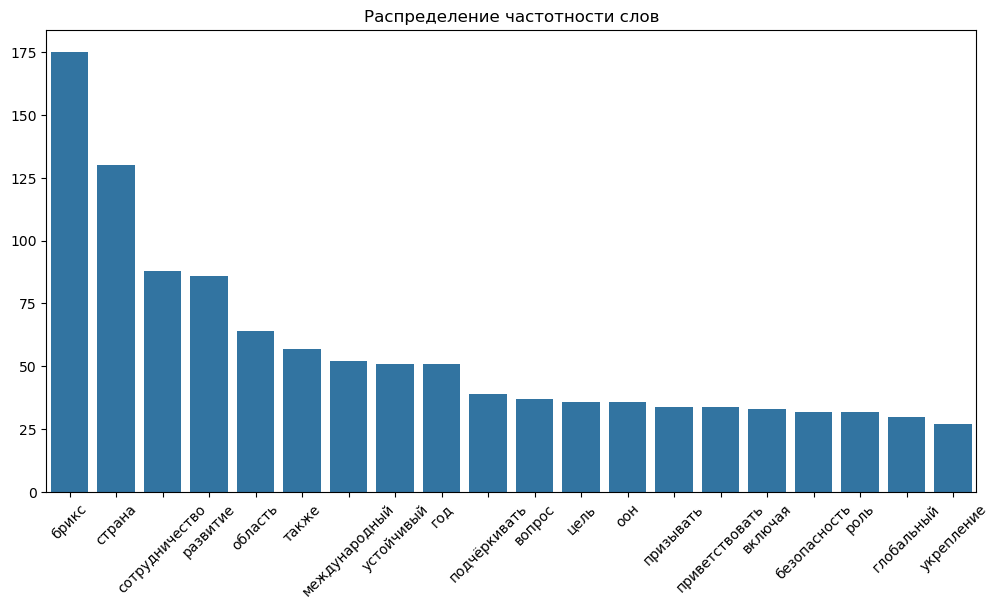

In [19]:
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [21]:
stop_words_ex = ['год','наш', 'который', 'также']
def stop_words_extra(text):
    return [w for w in text if not w in stop_words_ex]

In [23]:
tokens = stop_words_extra(tokenized)

C:\Temp\ipykernel_6272\3051857113.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


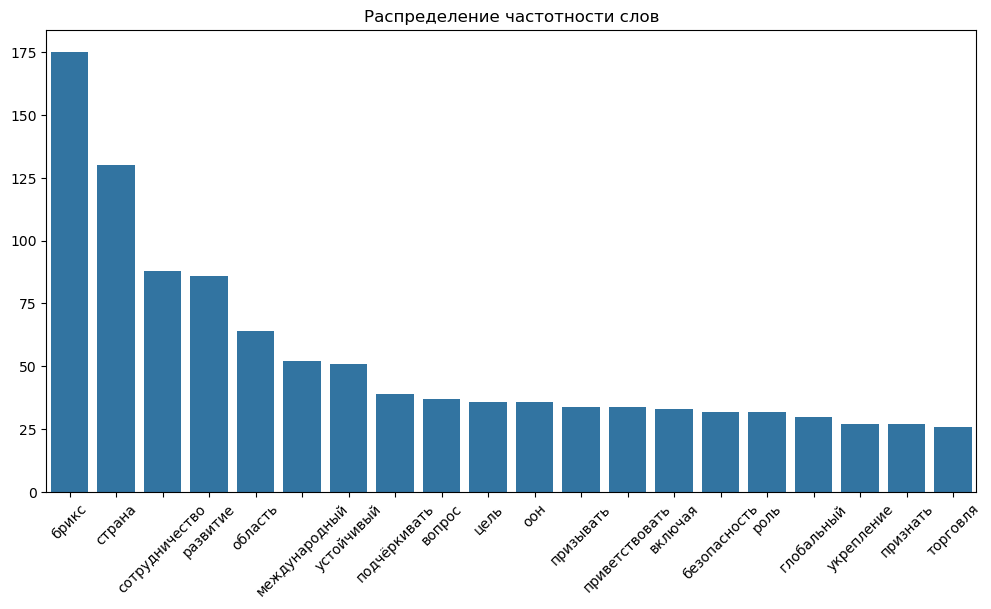

In [25]:
all_words = FreqDist(tokens)
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [27]:
textt = ','.join(w for w in tokens)

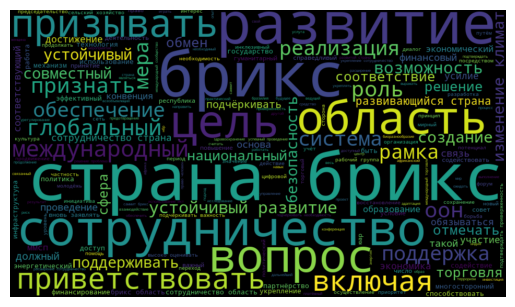

In [29]:
wordcloud = WordCloud(width=950,height=550).generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [31]:
# Приводим текст в векторное представление
tfidf_vect = TfidfVectorizer(max_df=1.0, min_df=2, stop_words=None)
doc_term_matrix = tfidf_vect.fit_transform(tokens)

### Латентное размещение Дерихле

In [34]:
LDA = LatentDirichletAllocation(n_components=2, random_state=42)
LDA.fit(doc_term_matrix)

LatentDirichletAllocation(n_components=2, random_state=42)

In [35]:
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['торговля', 'признать', 'укрепление', 'глобальный', 'включая', 'призывать', 'оон', 'цель', 'международный', 'брикс']


Top 10 words for topic #1:
['безопасность', 'роль', 'приветствовать', 'вопрос', 'подчёркивать', 'устойчивый', 'область', 'развитие', 'сотрудничество', 'страна']




In [36]:
LDA = LatentDirichletAllocation(n_components=3, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['реализация', 'решение', 'торговля', 'укрепление', 'признать', 'включая', 'призывать', 'оон', 'международный', 'брикс']


Top 10 words for topic #1:
['мера', 'обеспечение', 'экономика', 'безопасность', 'вопрос', 'устойчивый', 'область', 'развитие', 'сотрудничество', 'страна']


Top 10 words for topic #2:
['обмен', 'возможность', 'важность', 'поддержка', 'изменение', 'глобальный', 'роль', 'приветствовать', 'цель', 'подчёркивать']




Вывод: тематика декларации 2023 г. посвящена общим вопросам международного сотрудничества